In [38]:
import os
import re
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST', 'localhost')}:{os.getenv('DB_PORT', '5432')}"
    f"/{os.getenv('DB_NAME')}"
)

pd.read_sql("SELECT COUNT(*) AS n FROM hiring_signals", engine)

,n
0,62951


Setup;

## Geographic spread of semiconductor hiring

Where is each company actually staffing? Raw `location` strings are
unstandardized across the five ATS platforms (order, casing, spelling,
and granularity all differ — e.g. "India, Bengaluru" vs "Bengaluru,
Karnataka, India" vs bare "Bangalore"). This notebook normalizes each
string to a **country** and **region**, then compares cross-ticker
concentration (US vs Asia vs Europe, single-hub vs distributed).

**Known coverage gap:** Workday returns a count, not a place, for
multi-site postings ("2 Locations", "3 Locations", ...). Those are
bucketed as *Multiple (unspecified)* and reported, not hidden.

In [39]:
geo_raw = pd.read_sql("""
    WITH latest AS (SELECT MAX(snapshot_date) AS d FROM hiring_signals)
    SELECT ticker, ats, location
    FROM hiring_signals, latest
    WHERE snapshot_date = latest.d
""", engine)

print(f"{len(geo_raw):,} rows | snapshot = "
      f"{pd.read_sql('SELECT MAX(snapshot_date) AS d FROM hiring_signals', engine).iloc[0,0]}")
geo_raw.head()

11,573 rows | snapshot = 2026-06-01


,ticker,ats,location
0,MU,eightfold,"Boise, Idaho, United States of America"
1,MU,eightfold,"Taichung City, Taichung City, Taiwan"
2,MU,eightfold,"Boise, Idaho, United States of America"
3,MU,eightfold,"Singapore, Singapore"
4,MU,eightfold,"Hiroshima, Japan"


In [40]:
import unicodedata

COUNTRY_TOKENS = [
    ("united states of america", "United States"), ("united states", "United States"),
    ("usa", "United States"), ("us", "United States"),
    ("canada", "Canada"), ("mexico", "Mexico"), ("brazil", "Brazil"),
    ("argentina", "Argentina"), ("costa rica", "Costa Rica"),
    ("singapore", "Singapore"), ("sgp", "Singapore"),
    ("taiwan", "Taiwan"), ("india", "India"),
    ("prc", "China"), ("china", "China"), ("hong kong", "Hong Kong"),
    ("japan", "Japan"), ("south korea", "South Korea"), ("korea", "South Korea"),
    ("malaysia", "Malaysia"), ("philippines", "Philippines"),
    ("vietnam", "Vietnam"), ("thailand", "Thailand"), ("indonesia", "Indonesia"),
    ("israel", "Israel"), ("united arab emirates", "UAE"), ("uae", "UAE"),
    ("saudi arabia", "Saudi Arabia"),
    ("germany", "Germany"), ("france", "France"),
    ("united kingdom", "United Kingdom"), ("uk", "United Kingdom"),
    ("ireland", "Ireland"), ("greece", "Greece"), ("netherlands", "Netherlands"),
    ("switzerland", "Switzerland"), ("sweden", "Sweden"), ("finland", "Finland"),
    ("norway", "Norway"), ("denmark", "Denmark"), ("poland", "Poland"),
    ("italy", "Italy"), ("spain", "Spain"), ("belgium", "Belgium"),
    ("austria", "Austria"), ("czech", "Czechia"), ("romania", "Romania"),
    ("hungary", "Hungary"), ("australia", "Australia"),
    ("new zealand", "New Zealand"), ("egypt", "Egypt"), ("morocco", "Morocco"), ("cze", "Czechia"), 
    ("armenia","Armenia"),("turkiye","Turkey"),("turkey","Turkey"),("viet nam","Vietnam"),
]

REGION = {
    "United States": "North America", "Canada": "North America",
    "Mexico": "Latin America", "Brazil": "Latin America",
    "Argentina": "Latin America", "Costa Rica": "Latin America",
    "Singapore": "Asia", "Taiwan": "Asia", "India": "Asia", "China": "Asia",
    "Hong Kong": "Asia", "Japan": "Asia", "South Korea": "Asia",
    "Malaysia": "Asia", "Philippines": "Asia", "Vietnam": "Asia",
    "Thailand": "Asia", "Indonesia": "Asia",
    "Israel": "Middle East", "UAE": "Middle East", "Saudi Arabia": "Middle East",
    "Germany": "Europe", "France": "Europe", "United Kingdom": "Europe",
    "Ireland": "Europe", "Greece": "Europe", "Netherlands": "Europe",
    "Switzerland": "Europe", "Sweden": "Europe", "Finland": "Europe",
    "Norway": "Europe", "Denmark": "Europe", "Poland": "Europe", "Italy": "Europe",
    "Spain": "Europe", "Belgium": "Europe", "Austria": "Europe",
    "Czechia": "Europe", "Romania": "Europe", "Hungary": "Europe",
    "Australia": "Oceania", "New Zealand": "Oceania",
    "Egypt": "Africa", "Morocco": "Africa", "Palestinian Territories": "Middle East",
    "Armenia": "Middle East", "Turkey": "Middle East",
}

US_STATE_NAMES = [
    "alabama","alaska","arizona","arkansas","california","colorado","connecticut",
    "delaware","florida","georgia","hawaii","idaho","illinois","indiana","iowa",
    "kansas","kentucky","louisiana","maine","maryland","massachusetts","michigan",
    "minnesota","mississippi","missouri","montana","nebraska","nevada",
    "new hampshire","new jersey","new mexico","new york","north carolina",
    "north dakota","ohio","oklahoma","oregon","pennsylvania","rhode island",
    "south carolina","south dakota","tennessee","texas","utah","vermont",
    "virginia","washington","west virginia","wisconsin","wyoming",
]
US_STATE_ABBR = ["al","az","ar","ca","co","ct","de","fl","ga","id","il","in",
                 "ks","ky","la","ma","md","mi","mn","mo","ms","mt","nc","nd",
                 "ne","nh","nj","nm","nv","ny","oh","ok","or","pa","ri","sc",
                 "sd","tn","tx","ut","va","vt","wa","wi","wv","wy"]

# bare cities lacking any country/state token (seeded from the Unknown tail
# + obvious siblings; grouped by country for auditability)
CITY_OVERRIDES = [
    # United States (semis hubs)
    ("austin","United States"),("san jose","United States"),("santa clara","United States"),
    ("phoenix","United States"),("chandler","United States"),("hillsboro","United States"),
    ("portland","United States"),("folsom","United States"),("dallas","United States"),("plano","United States"),
    # India
    ("bangalore","India"),("bengaluru","India"),("hyderabad","India"),("pune","India"),
    ("noida","India"),("chennai","India"),("mumbai","India"),("new delhi","India"),
    ("delhi","India"),("gurgaon","India"),("gurugram","India"),("kolkata","India"),
    # China
    ("shanghai","China"),("beijing","China"),("nanjing","China"),("shenzhen","China"),
    ("suzhou","China"),("chengdu","China"),("hangzhou","China"),("xian","China"),
    # Taiwan
    ("hsinchu","Taiwan"),("zhubei","Taiwan"),("taipei","Taiwan"),("taichung","Taiwan"),
    ("taoyuan","Taiwan"),("kaohsiung","Taiwan"),("tainan","Taiwan"),
    # Japan
    ("yokohama","Japan"),("tokyo","Japan"),("osaka","Japan"),("nagoya","Japan"),("kyoto","Japan"),
    # South Korea
    ("seoul","South Korea"),("gyeonggi","South Korea"),("suwon","South Korea"),("incheon","South Korea"),
    # Vietnam / Singapore-area / Philippines
    ("ho chi minh","Vietnam"),("hanoi","Vietnam"),("manila","Philippines"),("cebu","Philippines"),
    # Ireland
    ("cork","Ireland"),("dublin","Ireland"),("limerick","Ireland"),("galway","Ireland"),
    # Israel
    ("yokneam","Israel"),("petah tikva","Israel"),("tel aviv","Israel"),
    ("haifa","Israel"),("herzliya","Israel"),("raanana","Israel"),("ramat gan","Israel"),
    # Greece / Malaysia / Brazil
    ("kato scholari","Greece"),("thessaloniki","Greece"),("athens","Greece"),
    ("penang","Malaysia"),("kuala lumpur","Malaysia"),("cyberjaya","Malaysia"),("kulim","Malaysia"),
    ("belo horizonte","Brazil"),("sao paulo","Brazil"),("campinas","Brazil"),
    # tail cleanup (1–4 jobs each)
    ("cary","United States"),("livonia","United States"),
    ("santa fe","United States"),("boston","United States"),
    ("vancouver","Canada"),("port moody","Canada"),("ottawa","Canada"),("toronto","Canada"),
    ("madrid","Spain"),("praha","Czechia"),("prague","Czechia"),
    ("edinburgh","United Kingdom"),("newcastle","United Kingdom"),("bracknell","United Kingdom"),
    ("da nang","Vietnam"),("riyadh","Saudi Arabia"),("guadalajara","Mexico"),
    ("cesson sevigne","France"),("rennes","France"),
    ("new south wales","Australia"),("adelaide","Australia"),("sydney","Australia"),("melbourne","Australia"),
    ("ahmedabad","India"),("brussels","Belgium"),("rawabi","Palestinian Territories"),
    # Additionals
    ("munich","Germany"),("feldkirchen","Germany"),("helsinki","Finland"),
    ("milan","Italy"),("rome","Italy"),("tavagnacco","Italy"),("pittsburgh","United States"),
    ("montreal","Canada"),("mount royal","Canada"),("velizy","France"),("valbonne","France"),
    ("istanbul","Turkey"),("jiangsu","China"),
]

def _has(token, text):
    return re.search(rf"(?<![a-z]){re.escape(token)}(?![a-z])", text) is not None

def _fold(text):                       # "Türkiye"->"turkiye", "Vélizy"->"velizy"
    return unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode()

def classify_location(loc):
    if loc is None or str(loc).strip() == "":
        return ("Unknown", "Unknown")
    s = str(loc).strip()
    if re.fullmatch(r"\d+\s+locations?", s, flags=re.I):
        return ("Multiple (unspecified)", "Multiple")
    raw_low = _fold(s.lower())
    norm = re.sub(r"[^a-z0-9 ]", " ", raw_low)
    m = re.fullmatch(r"home\s+([a-z]{2})", norm)        # "HOME MI" remote postings
    if m and m.group(1) in US_STATE_ABBR:
        return ("North America", "United States")
    for token, country in COUNTRY_TOKENS:
        if _has(token, norm):
            return (REGION[country], country)
    for st in US_STATE_NAMES:
        if _has(st, norm):
            return ("North America", "United States")
    for ab in US_STATE_ABBR:
        if re.search(rf",\s*{ab}(?![a-z])", raw_low):
            return ("North America", "United States")
    for token, country in CITY_OVERRIDES:
        if _has(token, norm):
            return (REGION[country], country)
    return ("Unknown", "Unknown")

geo = geo_raw.copy()
res_ = geo["location"].apply(classify_location)
geo["region"]  = res_.apply(lambda t: t[0])
geo["country"] = res_.apply(lambda t: t[1])
geo[["location", "country", "region"]].drop_duplicates().head(15)

,location,country,region
0,"Boise, Idaho, United States of America",United States,North America
1,"Taichung City, Taichung City, Taiwan",Taiwan,Asia
3,"Singapore, Singapore",Singapore,Asia
4,"Hiroshima, Japan",Japan,Asia
5,"Miaoli County, Miaoli County, Taiwan",Taiwan,Asia
6,"Hyderabad, Telangana, India",India,Asia
8,"Clay, New York, United States of America",United States,North America
9,"Taoyuan City, Taoyuan City, Taiwan",Taiwan,Asia
14,HSINCHU,Taiwan,Asia
16,2 Locations,Multiple,Multiple (unspecified)


In [41]:
total = len(geo)
resolved = geo[~geo["region"].isin(["Unknown", "Multiple (unspecified)"])].shape[0]
multiple = (geo["region"] == "Multiple (unspecified)").sum()
unknown  = (geo["region"] == "Unknown").sum()

print(f"Total jobs:            {total:,}")
print(f"Resolved to a region:  {resolved:,}  ({resolved/total:.1%})")
print(f"Multiple (unspecified):{multiple:,}  ({multiple/total:.1%})")
print(f"Unknown:               {unknown:,}  ({unknown/total:.1%})")
print("\nJobs by region:")
print(geo.groupby("region").size().sort_values(ascending=False).to_string())

print("\nTop 25 still-Unknown raw strings (these drive the next refinement):")
unknown_strings = (geo[geo["region"] == "Unknown"]
                   .groupby("location").size()
                   .sort_values(ascending=False).head(25))
print(unknown_strings.to_string())

Total jobs:            11,573
Resolved to a region:  10,076  (87.1%)
Multiple (unspecified):1,494  (12.9%)
Unknown:               3  (0.0%)

Jobs by region:
region
Asia                      5143
North America             3814
Multiple (unspecified)    1494
Europe                     434
Middle East                401
Latin America              276
Oceania                      8
Unknown                      3

Top 25 still-Unknown raw strings (these drive the next refinement):
location
             2
CAMBRIDGE    1


        n_jobs  pct_geo_resolved
ticker                          
MU        3024             100.0
NVDA      2654              61.2
QCOM      1985             100.0
AMD       1087             100.0
INTC       715              74.5
MRVL       677              84.5
CDNS       623              83.3
TXN        470             100.0
AVGO       338              77.2


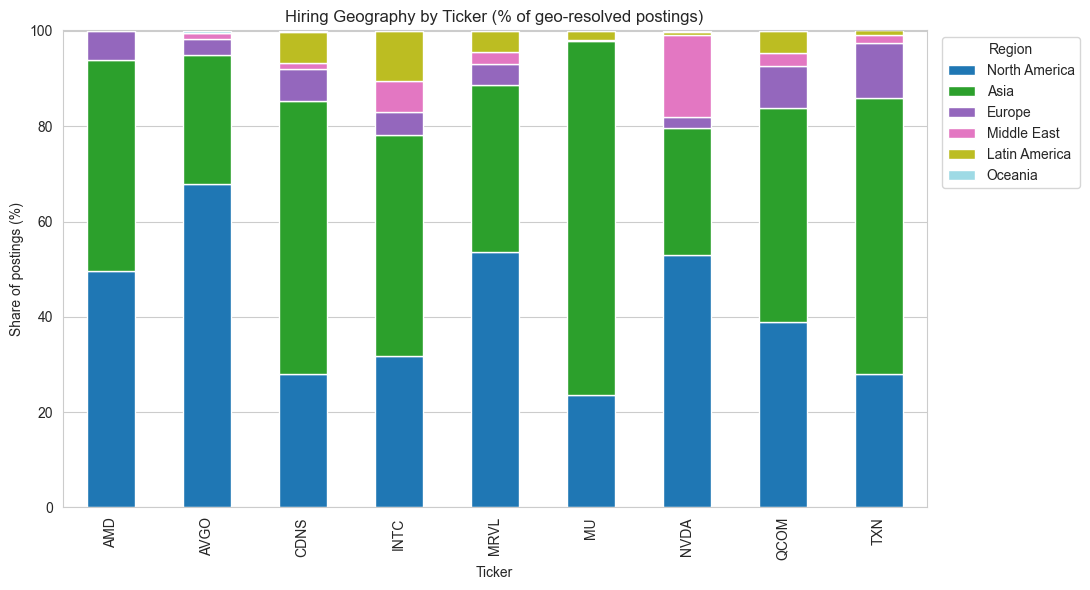

region,Asia,Europe,Latin America,Middle East,North America,Oceania
ticker,,,,,,
AMD,44.3,6.1,0.0,0.1,49.6,0.0
AVGO,27.2,3.4,0.0,1.1,67.8,0.4
CDNS,57.2,6.7,6.6,1.2,28.1,0.2
INTC,46.5,4.7,10.5,6.6,31.7,0.0
MRVL,35.1,4.5,4.4,2.4,53.5,0.0
MU,74.3,0.2,1.9,0.0,23.6,0.0
NVDA,26.7,2.4,0.6,17.2,52.9,0.2
QCOM,45.0,8.8,4.5,2.7,38.9,0.1
TXN,57.9,11.5,0.9,1.7,28.1,0.0


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

unresolved = ["Multiple (unspecified)", "Unknown"]

coverage = (geo.assign(resolved=~geo["region"].isin(unresolved))
               .groupby("ticker")
               .agg(n_jobs=("location", "size"), pct_geo_resolved=("resolved", "mean")))
coverage["pct_geo_resolved"] = (coverage["pct_geo_resolved"] * 100).round(1)
print(coverage.sort_values("n_jobs", ascending=False).to_string())

resolved_only = geo[~geo["region"].isin(unresolved)]
mix = pd.crosstab(resolved_only["ticker"], resolved_only["region"],
                  normalize="index").mul(100).round(1)

order = [r for r in ["North America","Asia","Europe","Middle East",
                     "Latin America","Oceania","Africa"] if r in mix.columns]
ax = mix[order].plot(kind="bar", stacked=True, figsize=(11, 6), colormap="tab20")
ax.set_title("Hiring Geography by Ticker (% of geo-resolved postings)")
ax.set_xlabel("Ticker"); ax.set_ylabel("Share of postings (%)")
ax.legend(title="Region", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()
mix

# per ticker region mix + coverage

In [43]:
shares = (resolved_only.groupby("ticker")["region"]
                       .value_counts(normalize=True).rename("share").reset_index())
top_region = (shares.sort_values("share", ascending=False)
                    .groupby("ticker").head(1).set_index("ticker"))
hhi = shares.groupby("ticker")["share"].apply(lambda s: (s**2).sum())

concentration = pd.DataFrame({
    "top_region": top_region["region"],
    "top_region_pct": (top_region["share"] * 100).round(1),
    "region_hhi": hhi.round(3),
}).sort_values("region_hhi", ascending=False)
concentration

# concentration metric (top region share + region HHI; near 1 = single-hub, low = distributed)

,top_region,top_region_pct,region_hhi
ticker,,,
MU,Asia,74.3,0.608
AVGO,North America,67.8,0.535
AMD,North America,49.6,0.445
TXN,Asia,57.9,0.427
CDNS,Asia,57.2,0.416
MRVL,North America,53.5,0.414
NVDA,North America,52.9,0.381
QCOM,Asia,45.0,0.364
INTC,Asia,46.5,0.335


In [44]:
top_countries = (resolved_only.groupby("country").size()
                              .sort_values(ascending=False).head(12))
print(top_countries.to_string())

# top countries overall

country
United States    3611
India            1732
Taiwan           1183
Singapore        1005
China             441
Israel            373
Japan             356
Malaysia          271
Canada            203
Mexico            201
Ireland            99
Germany            75


### Guided Observations — geographic spread (Day 10)

 - (COVERAGE CAVEAT) Region shares are computed over the ~87% of postings (10,076 of 11,573) that resolved to a country. The remaining 12.9% are Workday's multi-site postings, which return a count ("2 Locations" or more) instead of a place; they're bucketed as "Multiple (unspecified)" and excluded from the percentages. The gap isn't random — it falls almost entirely on the five Workday tickers and hits NVDA hardest (only 61.2% of its postings carry a usable location). So: trust the resolved shares, but read NVDA's regional split as the least complete of the nine

  - Given that Asia leads, this would mean that for a basket of US-Listed firms, they still hold a lot of their production and manufacturing to outside of the US given the high job count in Asia and there being higher headcount of possible hirees throughout a larger geographic range than just the USA.


  - The company that stands out is AMD and MU which have no presence within the Middle East at all, a stark contrast compared to NVDA who stands out in itself in the sense of holding the largest presence out of the semiconductor companies within the graph. Although NVDA only had locations for 61% of its jobs, we cannot be sure about its exact split because a good portion of NVDA's locations for their job listings were multiple regions meaning that we did not get a specific region that could further be contributed to the database for areas such as the Middle East but could've contained job locations within that area or for other areas.

  - The company that is most global is Intel with the most spread across regions making it unusual in the sense that they have the largest Latin America presence.

- **What to look at next:**
  Does the type of job change by region — e.g. is Asia more factory jobs while
  the US is more design/research jobs?

